# GAME THEORY MATRIX FINDER
### Exhaustive analysis of pure-strategy Nash equilibria in 2×2 payoff matrices

---

Each cell in this notebook contains either code or prose. Run a code cell with `Shift+Enter` — the output appears directly below. Markdown cells (like this one) are just text.


In [1]:
# ── Imports and global setup ────────────────────────────────────────────────
# Run this cell first — it loads every library the rest of the notebook needs.

import sys
import glob
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Make src/ importable from the project root
sys.path.insert(0, str(Path('engine').resolve()))

from src.theme import MPLSTYLE, ACCENT, BG_PAGE, BG_SURFACE, BG_ALT
from src.theme import BORDER_STRONG, TEXT_PRI, TEXT_MUT, TEXT_DIM, PALETTE
from src.matrix_permutations import find_nash_equilibria

# Apply the dark theme to every matplotlib figure in this notebook
plt.rcParams.update(MPLSTYLE)

# Paths
PROJECT_DIR  = Path('engine')
DATASETS_DIR = PROJECT_DIR / 'datasets'
MAIN_CSV     = DATASETS_DIR / 'matrices_2x2_0_to_5.csv'

# Skip files > 500 MB (e.g. 0-10 datasets are 8–24 GB — too large for notebook)
MAX_NB_BYTES = 500 * 1024 * 1024

# Suppress matplotlib findfont warnings (fires when a font isn't installed)
import logging as _logging
_logging.getLogger('matplotlib.font_manager').setLevel(_logging.ERROR)

# Game-type constants used across sections 06-08
GAME_TYPE_ORDER = [
    "Prisoner's Dilemma", "Harmony", "Deadlock", "Coordination",
    "Zero-Sum", "Dominant (P1 only)", "Dominant (P2 only)",
    "No Equilibrium", "Other",
]
GAME_TYPE_COLORS = {
    "Prisoner's Dilemma": "#E8610A",
    "Harmony":            "#4CAF82",
    "Deadlock":           "#C0392B",
    "Coordination":       "#3A9BD5",
    "Zero-Sum":           "#9B59B6",
    "Dominant (P1 only)": "#F39C12",
    "Dominant (P2 only)": "#E67E22",
    "No Equilibrium":     "#7A7570",
    "Other":              "#4A4540",
}

print('\u2713 Setup complete')
print(f'  Project dir : {PROJECT_DIR.resolve()}')
print(f'  Datasets dir: {DATASETS_DIR.resolve()}')

✓ Setup complete
  Project dir : <project-root>/engine
  Datasets dir: <project-root>/engine/datasets


---
## 01 / WHAT IS THIS PROJECT


### Background: 2-player payoff matrices and Nash equilibria

A **payoff matrix** is the fundamental object in two-player strategic-form game theory. Each row is a strategy for Player 1; each column is a strategy for Player 2. The cell at row *i*, column *j* contains two numbers — the payoff each player receives when they play strategies *i* and *j*.

```
              Col 0        Col 1
Row 0     (3, 3)       (0, 5)
Row 1     (5, 0)       (1, 1)   ← Nash equilibrium
```

A **pure-strategy Nash equilibrium (NE)** is a cell where neither player can improve their payoff by switching strategy unilaterally. In the example above (Prisoner's Dilemma), Row 1 / Col 1 is the unique NE: if Player 1 switches to Row 0 they go from 1 → 0; if Player 2 switches to Col 0 they also go from 1 → 0. Neither wants to deviate.

### What this project does

This codebase exhaustively enumerates every possible 2×2 payoff matrix for a given integer range, checks each one for Nash equilibria, and stores the results. With payoffs ranging 0–5 (6 values), there are **6² = 36 possible payoff pairs per cell** and **36⁴ = 1,679,616 distinct matrices**.

Key questions:
- What fraction of all possible matrices have a Nash equilibrium?
- How does that fraction change as the payoff range grows?
- Are there patterns in which configurations lead to more or fewer equilibria?

A note on range equivalence: only the **ordinal ranking** of payoffs matters for pure-strategy NE, not the absolute values. A 0–5 matrix and a 3–8 matrix with the same relative ordering are strategically identical. The integer ranges here are a discrete sampling of a continuous space — the empirical distributions correspond to the theoretical probabilities studied in the random games literature (Rinott, Scarsini et al.).


---
## 02 / STATISTICAL ANALYSIS


In [2]:
# Load the main dataset (0-5 range, 2×2 matrices)
print(f'Loading {MAIN_CSV.name} …')
df = pd.read_csv(MAIN_CSV)
print(f'Loaded {len(df):,} rows × {len(df.columns)} columns\n')

# Preview the first few rows
df.head()

Loading matrices_2x2_0_to_5.csv …


Loaded 1,679,616 rows × 11 columns



,top_left_1,top_left_2,top_right_1,top_right_2,bottom_left_1,bottom_left_2,bottom_right_1,bottom_right_2,num_equilibria,equilibrium_positions,category
0,0,0,0,0,0,0,0,0,4,"[(0, 0), (0, 1), (1, 0), (1, 1)]",Solved
1,0,0,0,0,0,0,0,1,3,"[(0, 0), (0, 1), (1, 1)]",Solved
2,0,0,0,0,0,0,0,2,3,"[(0, 0), (0, 1), (1, 1)]",Solved
3,0,0,0,0,0,0,0,3,3,"[(0, 0), (0, 1), (1, 1)]",Solved
4,0,0,0,0,0,0,0,4,3,"[(0, 0), (0, 1), (1, 1)]",Solved


In [3]:
# ── NE count distribution ───────────────────────────────────────────────────
ne_counts = df['num_equilibria'].value_counts().sort_index()
total = len(df)

print('Nash Equilibria Distribution')
print('─' * 40)
for ne_n, count in ne_counts.items():
    bar = '█' * int(40 * count / total)
    print(f'  {ne_n} NE  {bar}  {count:>9,}  ({100*count/total:5.2f}%)')

solved   = total - ne_counts.get(0, 0)
unsolved = ne_counts.get(0, 0)
print()
print(f'  SOLVED   (≥1 NE) : {solved:>9,}  ({100*solved/total:.2f}%)')
print(f'  UNSOLVED (0 NE)  : {unsolved:>9,}  ({100*unsolved/total:.2f}%)')

Nash Equilibria Distribution
────────────────────────────────────────
  0 NE  ██    101,250  ( 6.03%)
  1 NE  ██████████████████████    931,500  (55.46%)
  2 NE  █████████████    587,250  (34.96%)
  3 NE  █     58,320  ( 3.47%)
  4 NE        1,296  ( 0.08%)

  SOLVED   (≥1 NE) : 1,578,366  (93.97%)
  UNSOLVED (0 NE)  :   101,250  (6.03%)


In [4]:
# ── Interesting subsets ─────────────────────────────────────────────────────

# Matrices with ALL FOUR cells as Nash equilibria
df_4ne = df[df['num_equilibria'] == 4]
print(f'Matrices with 4 Nash equilibria: {len(df_4ne):,}')
print('Sample (first 5):')
display(df_4ne.head())

print()

# Unsolved matrices (no NE at all)
df_unsolved = df[df['num_equilibria'] == 0]
print(f'\nUnsolved matrices (0 NE): {len(df_unsolved):,}')
print('Sample payoff statistics for unsolved matrices:')
payoff_cols = [c for c in df.columns if c.endswith('_1') or c.endswith('_2')]
display(df_unsolved[payoff_cols].describe().round(2))

Matrices with 4 Nash equilibria: 1,296
Sample (first 5):


,top_left_1,top_left_2,top_right_1,top_right_2,bottom_left_1,bottom_left_2,bottom_right_1,bottom_right_2,num_equilibria,equilibrium_positions,category
0,0,0,0,0,0,0,0,0,4,"[(0, 0), (0, 1), (1, 0), (1, 1)]",Solved
37,0,0,0,0,0,1,0,1,4,"[(0, 0), (0, 1), (1, 0), (1, 1)]",Solved
74,0,0,0,0,0,2,0,2,4,"[(0, 0), (0, 1), (1, 0), (1, 1)]",Solved
111,0,0,0,0,0,3,0,3,4,"[(0, 0), (0, 1), (1, 0), (1, 1)]",Solved
148,0,0,0,0,0,4,0,4,4,"[(0, 0), (0, 1), (1, 0), (1, 1)]",Solved




Unsolved matrices (0 NE): 101,250
Sample payoff statistics for unsolved matrices:


,top_left_1,top_left_2,top_right_1,top_right_2,bottom_left_1,bottom_left_2,bottom_right_1,bottom_right_2
count,101250.00,101250.00,101250.00,101250.00,101250.00,101250.00,101250.00,101250.00
mean,2.50,2.50,2.50,2.50,2.50,2.50,2.50,2.50
std,1.71,1.71,1.71,1.71,1.71,1.71,1.71,1.71
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
50%,2.50,2.50,2.50,2.50,2.50,2.50,2.50,2.50
75%,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00
max,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00


In [5]:
# ── Summary statistics across the full dataset ──────────────────────────────
print('Full dataset summary statistics (payoff values only):')
payoff_cols = [c for c in df.columns if c.endswith('_1') or c.endswith('_2')]
df[payoff_cols].describe().round(2)

Full dataset summary statistics (payoff values only):


,top_left_1,top_left_2,top_right_1,top_right_2,bottom_left_1,bottom_left_2,bottom_right_1,bottom_right_2
count,1679616.00,1679616.00,1679616.00,1679616.00,1679616.00,1679616.00,1679616.00,1679616.00
mean,2.50,2.50,2.50,2.50,2.50,2.50,2.50,2.50
std,1.71,1.71,1.71,1.71,1.71,1.71,1.71,1.71
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
50%,2.50,2.50,2.50,2.50,2.50,2.50,2.50,2.50
75%,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00
max,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00


---
## 03 / VISUALISATIONS


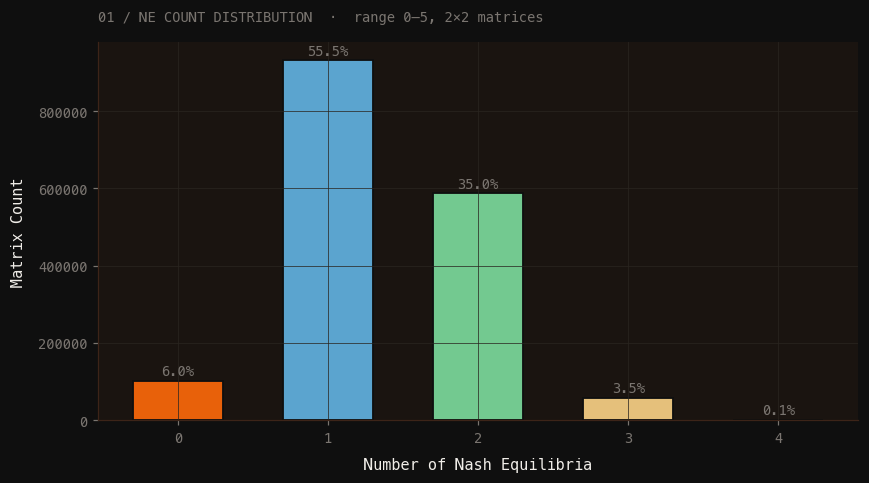

In [6]:
# ── Chart 1: NE count distribution (bar chart) ─────────────────────────────
ne_counts = df['num_equilibria'].value_counts().sort_index()
total     = len(df)

fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.bar(
    ne_counts.index,
    ne_counts.values,
    color=PALETTE[:len(ne_counts)],
    width=0.6,
    edgecolor=BG_PAGE,
    linewidth=1.2,
)

# Percentage labels on top of each bar
for bar, val in zip(bars, ne_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.004,
        f'{val/total*100:.1f}%',
        ha='center', va='bottom', fontsize=9, color=TEXT_MUT
    )

ax.set_xlabel('Number of Nash Equilibria', labelpad=8)
ax.set_ylabel('Matrix Count', labelpad=8)
ax.set_title('01 / NE COUNT DISTRIBUTION  ·  range 0–5, 2×2 matrices',
             loc='left', fontsize=9, color=TEXT_MUT)
ax.set_xticks(ne_counts.index)

plt.tight_layout()
plt.show()

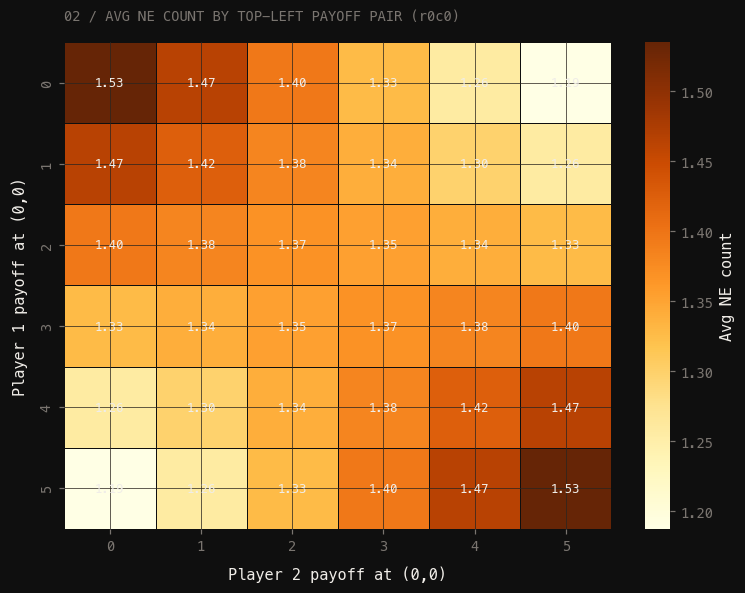

In [7]:
# ── Chart 2: Heatmap — avg NE count by top-left payoff pair ────────────────
#
# Question: does the payoff at position (0,0) predict the number of NE?
# We group by the two payoff values at the top-left cell and compute
# the mean NE count for all matrices sharing that cell.

# Check which column names exist
p1_col = 'r0c0_p1' if 'r0c0_p1' in df.columns else 'top_left_1'
p2_col = 'r0c0_p2' if 'r0c0_p2' in df.columns else 'top_left_2'

pivot = (
    df.groupby([p1_col, p2_col])['num_equilibria']
      .mean()
      .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(7, 5.5))

sns.heatmap(
    pivot,
    ax=ax,
    cmap='YlOrBr',
    linewidths=0.4,
    linecolor=BG_PAGE,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8, 'color': TEXT_PRI},
    cbar_kws={'label': 'Avg NE count'},
)

ax.set_title('02 / AVG NE COUNT BY TOP-LEFT PAYOFF PAIR (r0c0)',
             loc='left', fontsize=9, color=TEXT_MUT)
ax.set_xlabel('Player 2 payoff at (0,0)', labelpad=8)
ax.set_ylabel('Player 1 payoff at (0,0)', labelpad=8)
ax.tick_params(colors=TEXT_MUT)

plt.tight_layout()
plt.show()

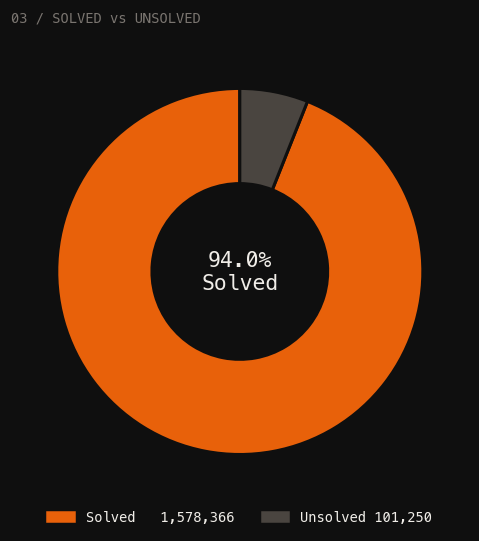

In [8]:
# ── Chart 3: Solved vs Unsolved donut ───────────────────────────────────────
unsolved = (df['num_equilibria'] == 0).sum()
solved   = len(df) - unsolved

fig, ax = plt.subplots(figsize=(5, 5))
wedges, _ = ax.pie(
    [solved, unsolved],
    colors=[ACCENT, TEXT_DIM],
    startangle=90,
    wedgeprops={'width': 0.52, 'edgecolor': BG_PAGE, 'linewidth': 2},
)
ax.text(0, 0, f'{100*solved/len(df):.1f}%\nSolved',
        ha='center', va='center', fontsize=14, color=TEXT_PRI,
        fontweight='bold')

ax.legend(
    handles=[
        mpatches.Patch(color=ACCENT,   label=f'Solved   {solved:,}'),
        mpatches.Patch(color=TEXT_DIM, label=f'Unsolved {unsolved:,}'),
    ],
    loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False
)
ax.set_title('03 / SOLVED vs UNSOLVED', loc='left', fontsize=9, color=TEXT_MUT)

plt.tight_layout()
plt.show()

---
## 04 / CROSS-RANGE COMPARISON

How does the NE distribution shift as the payoff range widens? With more distinct payoff values, ties become rarer — does that push the equilibrium rate up or down?

The 0–10 dataset (214M matrices) is too large to load directly, so its summary stats are pulled from the pre-computed `range_comparison.csv`.


In [9]:
# ── Load all available datasets ─────────────────────────────────────────────
_sk = lambda p: (p.stem.split('_')[1], int(p.stem.split('_to_')[-1]))
csv_files = [p for p in sorted(DATASETS_DIR.glob('matrices_*.csv'), key=_sk)
             if p.stat().st_size <= MAX_NB_BYTES]
print(f'Found {len(csv_files)} dataset(s):')
for f in csv_files:
    print(f'  {f.name}')

Found 4 dataset(s):
  matrices_2x2_0_to_2.csv
  matrices_2x2_0_to_3.csv
  matrices_2x2_0_to_5.csv
  matrices_3x3_0_to_1.csv


In [10]:
# ── Build comparison summary ─────────────────────────────────────────────────
summaries = []
for fpath in csv_files:
    d = pd.read_csv(fpath)
    total = len(d)
    stem   = fpath.stem.replace('matrices_', '')
    parts  = stem.split('_')
    try:
        size = parts[0].replace('x', '×')
        lo, hi = parts[1], parts[3]
        label = f'{size} · {lo}–{hi}'
    except IndexError:
        label = stem

    row = {'label': label, 'total': total}
    vc  = d['num_equilibria'].value_counts()
    for i in range(5):
        row[f'{i}_NE_pct'] = vc.get(i, 0) / total * 100
    row['solved_pct'] = (total - vc.get(0, 0)) / total * 100
    summaries.append(row)

# Append large datasets from pre-computed range_comparison.csv
_rc = pd.read_csv(DATASETS_DIR / 'range_comparison.csv')
_loaded_labels = {s['label'] for s in summaries}
for _, r in _rc.iterrows():
    _label = f"{r['matrix']} · {r['range']}"
    if _label not in _loaded_labels:
        _total = int(r['total'])
        _row = {'label': _label, 'total': _total}
        for i in range(5):
            col = f'{i}_NE'
            raw = str(r.get(col, '0'))
            count = int(raw.split()[0].replace(',', ''))
            _row[f'{i}_NE_pct'] = count / _total * 100
        _pct = float(str(r['pct_solved']).replace('%', ''))
        _row['solved_pct'] = _pct
        summaries.append(_row)

# Sort by matrix size then upper bound
def _sort_key(s):
    parts = s['label'].split(' · ')
    try: return (parts[0], int(parts[1].split('–')[1]))
    except: return (parts[0], 0)
summaries.sort(key=_sort_key)

comparison = pd.DataFrame(summaries)
print('Comparison summary:')
display(comparison)


Comparison summary:


,label,total,0_NE_pct,1_NE_pct,2_NE_pct,3_NE_pct,4_NE_pct,solved_pct
0,2×2 · 0–2,6561,2.469136,34.567901,46.913580,14.814815,1.234568,97.530864
1,2×2 · 0–3,65536,3.955078,44.824219,42.626953,8.203125,0.390625,96.044922
2,2×2 · 0–5,1679616,6.028164,55.459105,34.963349,3.472222,0.077160,93.971836
3,2×2 · 0–10,214358881,8.537668,64.886278,25.613005,0.956219,0.006830,91.460000
4,3×3 · 0–1,262144,0.544739,5.544662,17.619324,27.708435,25.467682,99.455261


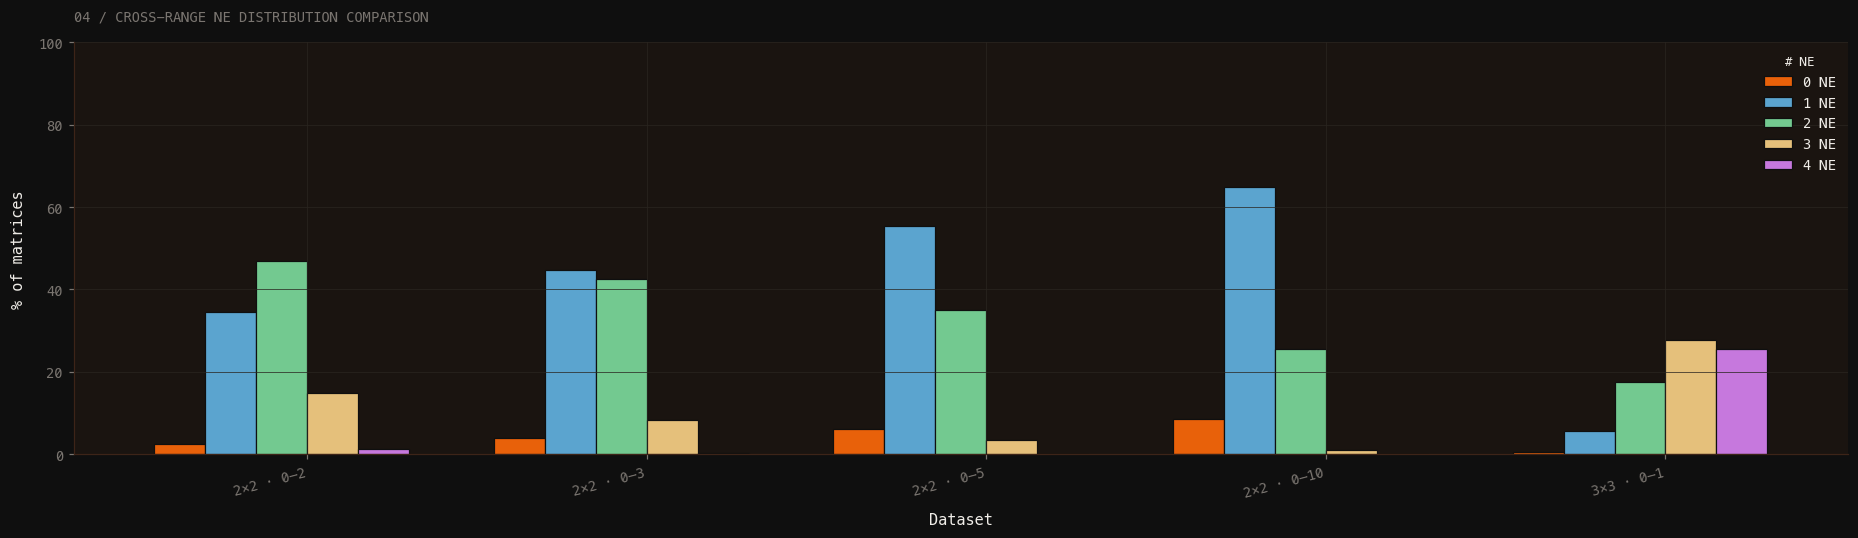

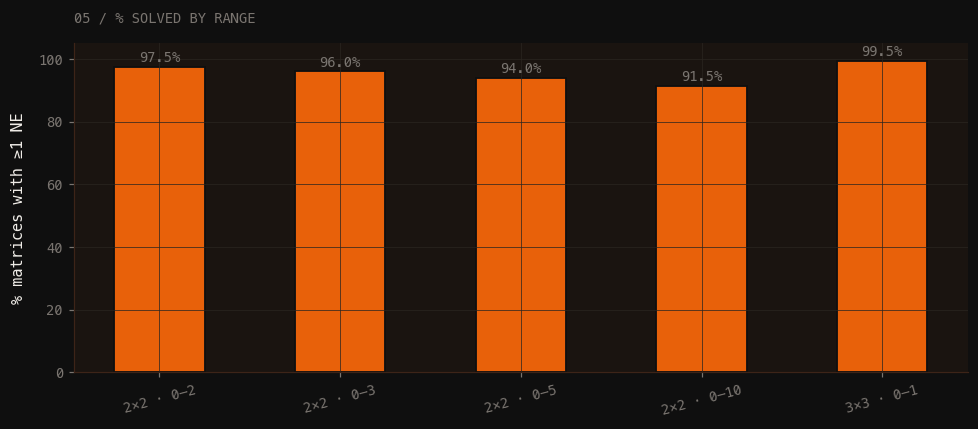

In [11]:
# ── Chart 4: Grouped bar chart across ranges ─────────────────────────────────
if len(comparison) > 1:
    labels   = comparison['label'].tolist()
    x        = np.arange(len(labels))
    width    = 0.15
    ne_cols  = [c for c in comparison.columns if c.endswith('_NE_pct')]

    fig, ax = plt.subplots(figsize=(max(9, len(labels)*3+2), 5))
    for i, col in enumerate(ne_cols):
        ne_n = int(col.split('_')[0])
        ax.bar(x + i*width, comparison[col], width,
               label=f'{ne_n} NE',
               color=PALETTE[i % len(PALETTE)],
               edgecolor=BG_PAGE, linewidth=0.8)

    ax.set_xlabel('Dataset', labelpad=8)
    ax.set_ylabel('% of matrices', labelpad=8)
    ax.set_title('04 / CROSS-RANGE NE DISTRIBUTION COMPARISON',
                 loc='left', fontsize=9, color=TEXT_MUT)
    ax.set_xticks(x + width * len(ne_cols) / 2)
    ax.set_xticklabels(labels, rotation=15, ha='right')
    ax.legend(title='# NE', framealpha=0, title_fontsize=8)
    ax.set_ylim(0, 100)
    plt.tight_layout()
    plt.show()
else:
    print('Only one dataset available — run generate_datasets.py to add more ranges.')
    print('Then re-run this cell to see the comparison.')

# ── Chart 5: % Solved across ranges ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(6, len(comparison)*1.8), 4))
bars = ax.bar(comparison['label'], comparison['solved_pct'],
              color=ACCENT, edgecolor=BG_PAGE, linewidth=1.2, width=0.5)

for bar, val in zip(bars, comparison['solved_pct']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, color=TEXT_MUT)

ax.set_ylabel('% matrices with ≥1 NE', labelpad=8)
ax.set_title('05 / % SOLVED BY RANGE', loc='left', fontsize=9, color=TEXT_MUT)
ax.set_ylim(0, 105)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

---
## 05 / INTERACTIVE MATRIX EXPLORER

Drag the sliders to set payoffs for any 2×2 matrix and see the Nash equilibria computed live. The Gradio app (`app.py`) does the same thing as a full web interface — this is the notebook equivalent for quick exploration.


In [12]:
import ipywidgets as widgets
from IPython.display import display, HTML

# ── Build the interactive explorer ──────────────────────────────────────────

SLIDER_STYLE = {'description_width': '80px'}
SLIDER_LAYOUT = widgets.Layout(width='280px')

def make_slider(label, value=0):
    return widgets.IntSlider(
        value=value, min=0, max=10,
        description=label,
        style=SLIDER_STYLE, layout=SLIDER_LAYOUT,
        continuous_update=True,
    )

# Eight sliders — two per cell (Player 1 and Player 2 payoffs)
s_r0c0_p1 = make_slider('(0,0) P1', 3)
s_r0c0_p2 = make_slider('(0,0) P2', 3)
s_r0c1_p1 = make_slider('(0,1) P1', 0)
s_r0c1_p2 = make_slider('(0,1) P2', 5)
s_r1c0_p1 = make_slider('(1,0) P1', 5)
s_r1c0_p2 = make_slider('(1,0) P2', 0)
s_r1c1_p1 = make_slider('(1,1) P1', 1)
s_r1c1_p2 = make_slider('(1,1) P2', 1)

output = widgets.Output()

def update(*args):
    matrix = np.array([
        [[s_r0c0_p1.value, s_r0c0_p2.value], [s_r0c1_p1.value, s_r0c1_p2.value]],
        [[s_r1c0_p1.value, s_r1c0_p2.value], [s_r1c1_p1.value, s_r1c1_p2.value]],
    ], dtype=np.int32)

    eq = find_nash_equilibria(matrix)
    ne_set = set(eq)

    # Build HTML table
    rows_html = ''
    for r in range(2):
        row_cells = ''
        for c in range(2):
            p1 = matrix[r, c, 0]
            p2 = matrix[r, c, 1]
            is_ne = (r, c) in ne_set
            style = (
                f'padding:14px 24px;border:1px solid {BORDER_STRONG};'
                f'background:{BG_ALT};text-align:center;font-size:1.1rem;'
            )
            content = f'({p1}, {p2})'
            if is_ne:
                style += f'color:{ACCENT};font-weight:700;'
                content += ' ★'
            else:
                style += f'color:{TEXT_MUT};'
            row_cells += f'<td style="{style}">{content}</td>'
        rows_html += f'<tr>{row_cells}</tr>'

    table = (
        f'<table style="border-collapse:collapse;font-family:monospace;'
        f'margin:auto;">'
        f'<tr>'
        f'<th style="padding:6px 24px;color:{TEXT_DIM};font-size:0.7rem;border:1px solid {BORDER_STRONG};">Col 0</th>'
        f'<th style="padding:6px 24px;color:{TEXT_DIM};font-size:0.7rem;border:1px solid {BORDER_STRONG};">Col 1</th>'
        f'</tr>'
        f'{rows_html}'
        f'</table>'
    )

    if not eq:
        verdict = f'<p style="color:{TEXT_MUT};font-family:monospace;margin-top:0.8rem;">⚠ No pure-strategy Nash equilibrium.</p>'
    else:
        pos_str = ', '.join(f'({r},{c})' for r,c in eq)
        verdict = (
            f'<p style="font-family:monospace;margin-top:0.8rem;">'
            f'✓ <strong style="color:{ACCENT}">{len(eq)} NE</strong> at: {pos_str}</p>'
        )

    with output:
        output.clear_output(wait=True)
        display(HTML(f'<div style="text-align:center;padding:1rem;background:{BG_SURFACE};border-radius:6px;">'
                     f'{table}{verdict}</div>'))

# Wire all sliders to the update function
for s in [s_r0c0_p1, s_r0c0_p2, s_r0c1_p1, s_r0c1_p2,
          s_r1c0_p1, s_r1c0_p2, s_r1c1_p1, s_r1c1_p2]:
    s.observe(update, names='value')

# Layout
top_row    = widgets.HBox([s_r0c0_p1, s_r0c0_p2, s_r0c1_p1, s_r0c1_p2])
bottom_row = widgets.HBox([s_r1c0_p1, s_r1c0_p2, s_r1c1_p1, s_r1c1_p2])
header_top = widgets.HTML(f'<div style="color:{TEXT_DIM};font-family:monospace;font-size:0.7rem;text-transform:uppercase;">Top row &nbsp;·&nbsp; Row 0</div>')
header_bot = widgets.HTML(f'<div style="color:{TEXT_DIM};font-family:monospace;font-size:0.7rem;text-transform:uppercase;">Bottom row &nbsp;·&nbsp; Row 1</div>')

ui = widgets.VBox([header_top, top_row, header_bot, bottom_row, output])

# Initial render
update()
display(ui)

---


---
## 06 / GAME TYPE ANALYSIS

Beyond counting equilibria — classifying what *kind* of game each matrix represents.

Named game types carry theoretical weight: knowing a matrix is a Prisoner's Dilemma tells you immediately that rational players reach a suboptimal outcome and cooperation requires external enforcement. The `src/analysis.py` module classifies each matrix into boolean structural properties (does P1 have a dominant strategy? is the game zero-sum? is the NE Pareto-efficient?) and derives a named type from those in a fixed priority order.


In [13]:
# ── Load enriched datasets ───────────────────────────────────────────────────
# enrich_datasets.py adds game_type + structural boolean columns to each CSV.
# Run it first: python enrich_datasets.py

from src.analysis import classify_full, GAME_TYPE_DESCRIPTIONS
from src.matrix_permutations import find_nash_equilibria

ENRICHED_DIR = DATASETS_DIR / 'enriched'

enriched_files = sorted(ENRICHED_DIR.glob('matrices_*.csv'))
print(f'Found {len(enriched_files)} enriched dataset(s):')
for f in enriched_files:
    print(f'  {f.name}')

if not enriched_files:
    print()
    print('No enriched datasets found.')
    print('Run this from the project directory:')
    print('  python enrich_datasets.py')


Found 5 enriched dataset(s):
  matrices_2x2_0_to_10.csv
  matrices_2x2_0_to_2.csv
  matrices_2x2_0_to_3.csv
  matrices_2x2_0_to_5.csv
  matrices_3x3_0_to_1.csv


In [14]:
# ── Load the main enriched dataset (0-5 range) for analysis ─────────────────
ENRICHED_CSV = ENRICHED_DIR / 'matrices_2x2_0_to_5.csv'

if ENRICHED_CSV.exists():
    print(f'Loading {ENRICHED_CSV.name} …')
    edf = pd.read_csv(ENRICHED_CSV)
    print(f'Loaded {len(edf):,} rows × {len(edf.columns)} columns')
    print(f'\nNew classification columns:')
    class_cols = ['p1_has_dominant','p2_has_dominant','both_dominant',
                  'is_zero_sum','is_symmetric','has_pareto_dom_ne',
                  'all_ne_pareto_eff','max_welfare','ne_welfare','welfare_loss','game_type']
    for c in class_cols:
        if c in edf.columns:
            sample = edf[c].iloc[0]
            print(f'  {c:<22} → {sample!r}')
    print()
    edf[['game_type','welfare_loss','both_dominant','is_zero_sum']].head(8)
else:
    print(f'File not found: {ENRICHED_CSV}')
    print('Run: python enrich_datasets.py')
    edf = None


Loading matrices_2x2_0_to_5.csv …


Loaded 1,679,616 rows × 32 columns

New classification columns:
  p1_has_dominant        → True
  p2_has_dominant        → True
  both_dominant          → True
  is_zero_sum            → True
  is_symmetric           → True
  has_pareto_dom_ne      → False
  all_ne_pareto_eff      → True
  max_welfare            → 0
  ne_welfare             → '[0, 0, 0, 0]'
  welfare_loss           → 0
  game_type              → 'Zero-Sum'



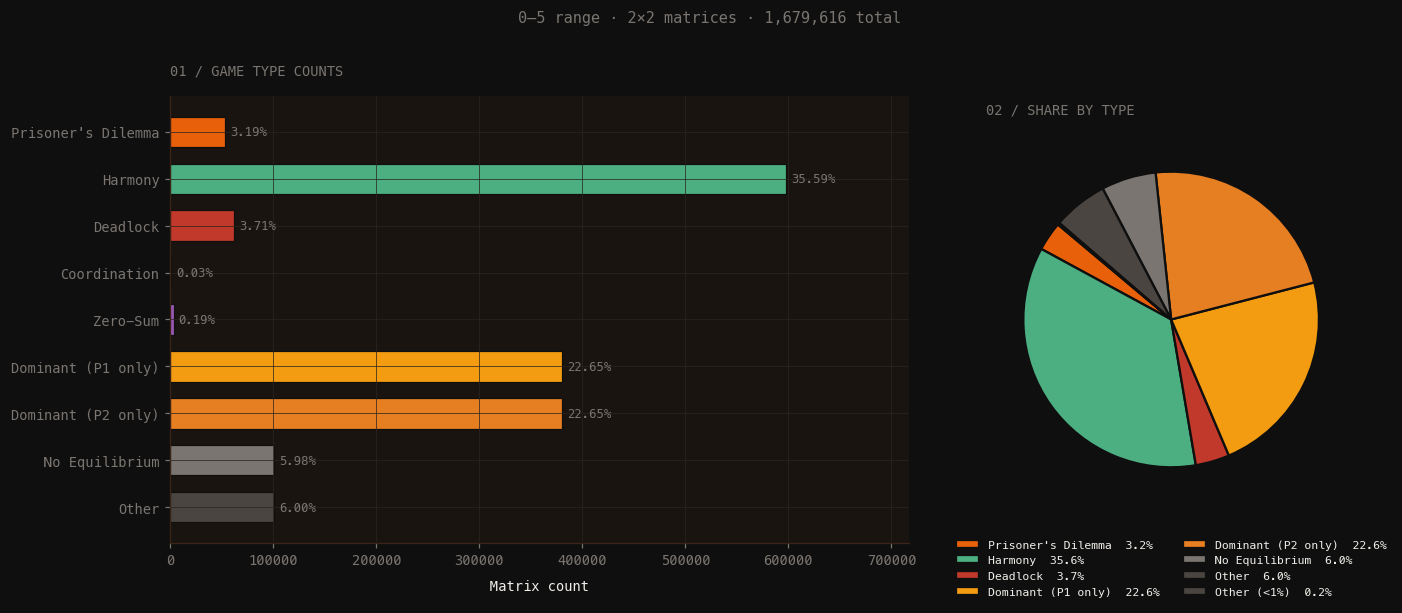

In [15]:
# ── Chart 06-A: Game type distribution — horizontal bar + pie ───────────────
if edf is not None:
    counts = edf['game_type'].value_counts()
    total  = len(edf)

    ordered_labels = [t for t in GAME_TYPE_ORDER if t in counts.index]
    ordered_labels += [t for t in counts.index if t not in GAME_TYPE_ORDER]
    ordered_vals   = [counts[t] for t in ordered_labels]
    colors         = [GAME_TYPE_COLORS.get(t, TEXT_DIM) for t in ordered_labels]

    fig, (ax_bar, ax_pie) = plt.subplots(
        1, 2, figsize=(13, max(4.5, len(ordered_labels) * 0.6)),
        gridspec_kw={'width_ratios': [2, 1]},
    )
    fig.suptitle('0–5 range · 2×2 matrices · 1,679,616 total',
                 fontsize=10, color=TEXT_MUT, fontfamily='monospace', y=1.01)

    # Horizontal bar chart
    y_pos = np.arange(len(ordered_labels))
    bars  = ax_bar.barh(y_pos, ordered_vals, color=colors,
                        edgecolor=BG_PAGE, linewidth=0.8, height=0.65)
    ax_bar.set_yticks(y_pos)
    ax_bar.set_yticklabels(ordered_labels, fontsize=9)
    ax_bar.set_xlabel('Matrix count', labelpad=8, fontsize=9)
    ax_bar.set_title('01 / GAME TYPE COUNTS', loc='left',
                     fontfamily='monospace', fontsize=9, color=TEXT_MUT)
    ax_bar.invert_yaxis()

    for bar, val in zip(bars, ordered_vals):
        pct = 100 * val / total
        ax_bar.text(bar.get_width() + total * 0.003,
                    bar.get_y() + bar.get_height() / 2,
                    f'{pct:.2f}%', va='center', fontsize=8, color=TEXT_MUT)
    ax_bar.set_xlim(0, max(ordered_vals) * 1.2)

    # Pie chart (group < 1% slices)
    display_vals, display_labels, display_colors, other_v = [], [], [], 0
    for lbl, val, col in zip(ordered_labels, ordered_vals, colors):
        if val / total < 0.01 and lbl != 'Other':
            other_v += val
        else:
            display_vals.append(val); display_labels.append(lbl); display_colors.append(col)
    if other_v:
        display_vals.append(other_v); display_labels.append('Other (<1%)'); display_colors.append(TEXT_DIM)

    wedges, _ = ax_pie.pie(display_vals, colors=display_colors, startangle=140,
                            wedgeprops={'edgecolor': BG_PAGE, 'linewidth': 1.5})
    ax_pie.legend(wedges,
                  [f'{l}  {100*v/total:.1f}%' for l, v in zip(display_labels, display_vals)],
                  loc='lower center', bbox_to_anchor=(0.5, -0.28),
                  fontsize=7.5, ncol=2, frameon=False)
    ax_pie.set_title('02 / SHARE BY TYPE', loc='left',
                     fontfamily='monospace', fontsize=9, color=TEXT_MUT)

    plt.tight_layout()
    plt.show()


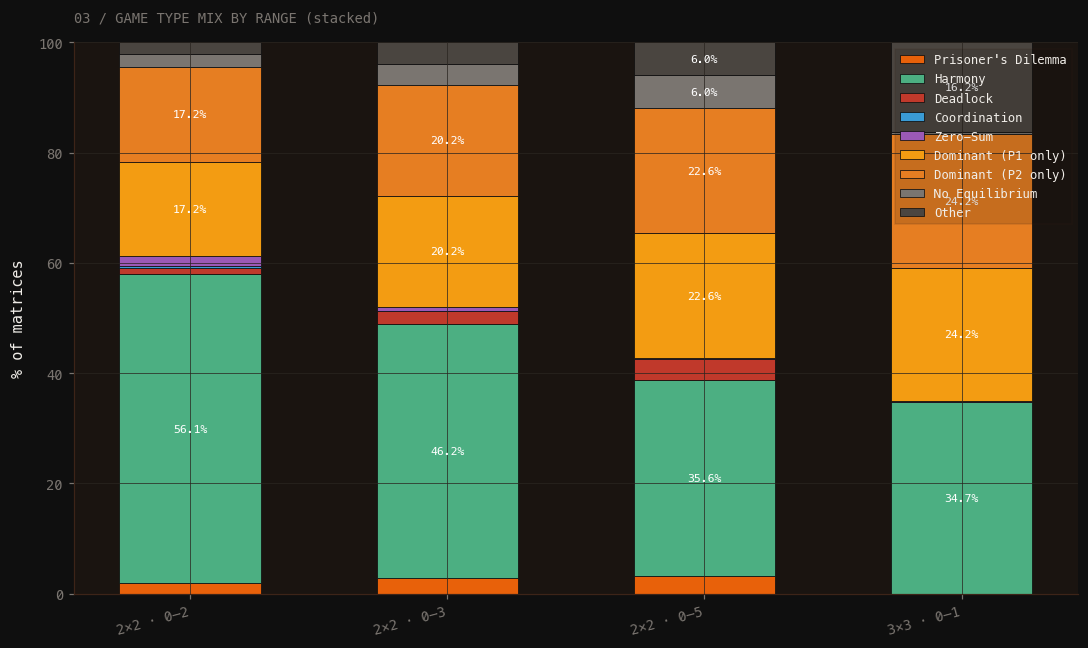

In [16]:
# ── Chart 06-B: Game type mix across ranges (stacked bar) ──────────────────
#
# Load all available enriched datasets and show how game type proportions
# change as the payoff range widens.
#
# Key question: does "Prisoner's Dilemma" become more or less common
# when payoffs can span 0–10 instead of 0–5?

range_summaries = []
_sk = lambda p: (p.stem.split('_')[1], int(p.stem.split('_to_')[-1]))
for fpath in sorted((p for p in ENRICHED_DIR.glob('matrices_*.csv')
                     if p.stat().st_size <= MAX_NB_BYTES), key=_sk):
    d = pd.read_csv(fpath)
    total = len(d)
    stem  = fpath.stem.replace('matrices_', '')
    parts = stem.split('_')
    try:
        label = f"{parts[0].replace('x','×')} · {parts[1]}–{parts[3]}"
    except IndexError:
        label = stem

    vc  = d['game_type'].value_counts()
    row = {'label': label, 'total': total}
    for gt in GAME_TYPE_ORDER:
        row[gt] = vc.get(gt, 0) / total * 100
    range_summaries.append(row)

if len(range_summaries) >= 2:
    rdf    = pd.DataFrame(range_summaries)
    labels = rdf['label'].tolist()
    x      = np.arange(len(labels))
    width  = 0.55

    fig, ax = plt.subplots(figsize=(max(8, len(labels) * 2.5), 6))

    bottoms = np.zeros(len(labels))
    for gt in GAME_TYPE_ORDER:
        if gt in rdf.columns:
            vals = rdf[gt].values
            bars = ax.bar(x, vals, width, bottom=bottoms,
                          label=gt,
                          color=GAME_TYPE_COLORS.get(gt, TEXT_DIM),
                          edgecolor=BG_PAGE, linewidth=0.5)
            # Label slices that are big enough to read
            for xi, (v, b) in enumerate(zip(vals, bottoms)):
                if v > 4:
                    ax.text(xi, b + v/2, f'{v:.1f}%',
                            ha='center', va='center', fontsize=7.5,
                            color='white', fontweight='600')
            bottoms += vals

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('% of matrices', labelpad=8)
    ax.set_ylim(0, 100)
    ax.set_title('03 / GAME TYPE MIX BY RANGE (stacked)',
                 loc='left', fontfamily='monospace', fontsize=9, color=TEXT_MUT)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.15,
              fancybox=False, edgecolor=BORDER_STRONG)
    plt.tight_layout()
    plt.show()
elif len(range_summaries) == 1:
    print('Only one enriched dataset found — run enrich_datasets.py for all ranges.')
    print('Showing single-range summary:')
    print(pd.DataFrame(range_summaries).T)
else:
    print('No enriched datasets found. Run: python enrich_datasets.py')


Matrices with ≥1 NE: 1,578,366
  All NE Pareto-efficient  : 1,015,146  (64.32%)
  Has Pareto-dominated NE  : 563,220  (35.68%)



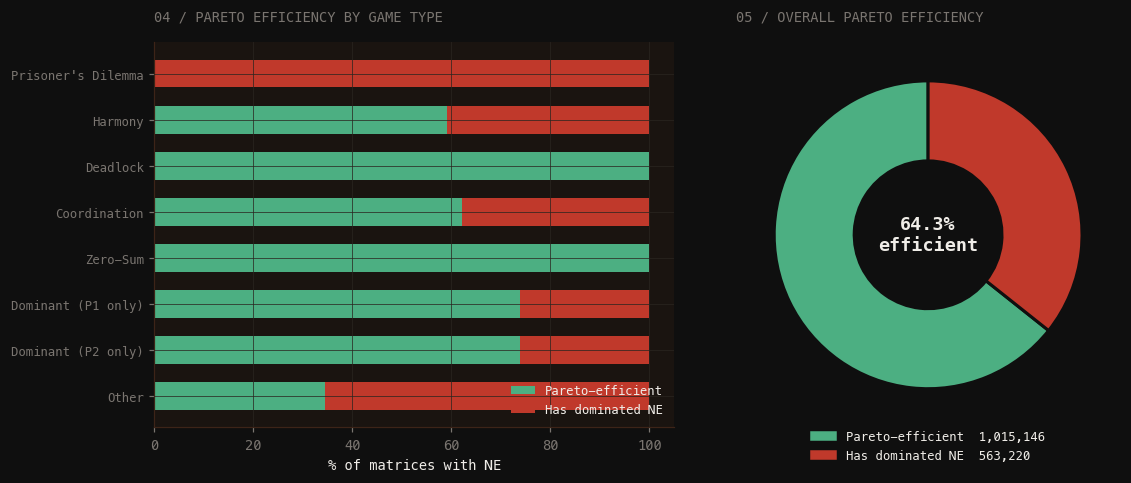

In [17]:
# ── Chart 06-C: Pareto efficiency of Nash equilibria ────────────────────────
#
# For each matrix with at least one NE, is that NE socially optimal?
# "Pareto-efficient" means no cell beats the NE for both players simultaneously.
#
# A matrix where the NE is NOT Pareto-efficient is the hallmark of a social dilemma:
# there's a better outcome neither player will reach through rational self-interest.

if edf is not None:
    # Focus on matrices that have at least one NE
    has_ne = edf[edf['num_equilibria'] > 0].copy()
    total_ne = len(has_ne)

    pareto_eff   = (has_ne['all_ne_pareto_eff'] == True).sum()
    pareto_ineff = total_ne - pareto_eff
    pct_eff      = 100 * pareto_eff / total_ne

    print(f'Matrices with ≥1 NE: {total_ne:,}')
    print(f'  All NE Pareto-efficient  : {pareto_eff:,}  ({pct_eff:.2f}%)')
    print(f'  Has Pareto-dominated NE  : {pareto_ineff:,}  ({100-pct_eff:.2f}%)')
    print()

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    # Left: stacked bar by game type — Pareto-efficient vs not
    gt_pareto = (
        has_ne.groupby('game_type')['all_ne_pareto_eff']
              .value_counts(normalize=True)
              .unstack(fill_value=0)
              .reindex(GAME_TYPE_ORDER)
              .dropna(how='all')
    )
    ax = axes[0]
    y_pos = np.arange(len(gt_pareto))
    eff_vals   = gt_pareto.get(True,  pd.Series(0, index=gt_pareto.index)).values * 100
    ineff_vals = gt_pareto.get(False, pd.Series(0, index=gt_pareto.index)).values * 100

    ax.barh(y_pos, eff_vals,   label='Pareto-efficient',   color='#4CAF82', height=0.6)
    ax.barh(y_pos, ineff_vals, label='Has dominated NE',   color='#C0392B', height=0.6,
            left=eff_vals)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(gt_pareto.index, fontsize=8)
    ax.set_xlabel('% of matrices with NE', fontsize=9)
    ax.set_title('04 / PARETO EFFICIENCY BY GAME TYPE',
                 loc='left', fontfamily='monospace', fontsize=9, color=TEXT_MUT)
    ax.invert_yaxis()
    ax.legend(fontsize=8, framealpha=0, loc='lower right')
    ax.set_xlim(0, 105)

    # Right: overall donut
    ax2 = axes[1]
    wedges, _ = ax2.pie(
        [pareto_eff, pareto_ineff],
        colors=['#4CAF82', '#C0392B'],
        startangle=90,
        wedgeprops={'width': 0.52, 'edgecolor': BG_PAGE, 'linewidth': 2},
    )
    ax2.text(0, 0, f'{pct_eff:.1f}%\nefficient',
             ha='center', va='center', fontsize=12, color=TEXT_PRI,
             fontweight='bold', fontfamily='monospace')
    ax2.legend(handles=[
        mpatches.Patch(color='#4CAF82', label=f'Pareto-efficient  {pareto_eff:,}'),
        mpatches.Patch(color='#C0392B', label=f'Has dominated NE  {pareto_ineff:,}'),
    ], loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=1, frameon=False, fontsize=8)
    ax2.set_title('05 / OVERALL PARETO EFFICIENCY',
                  loc='left', fontfamily='monospace', fontsize=9, color=TEXT_MUT)

    plt.tight_layout()
    plt.show()


Welfare loss distribution (matrices with ≥1 NE):


  welfare_loss == 0 : 1,322,310  (83.78%)  ← no social loss
  welfare_loss  > 0 :   256,056  (16.22%)  ← some welfare left on table



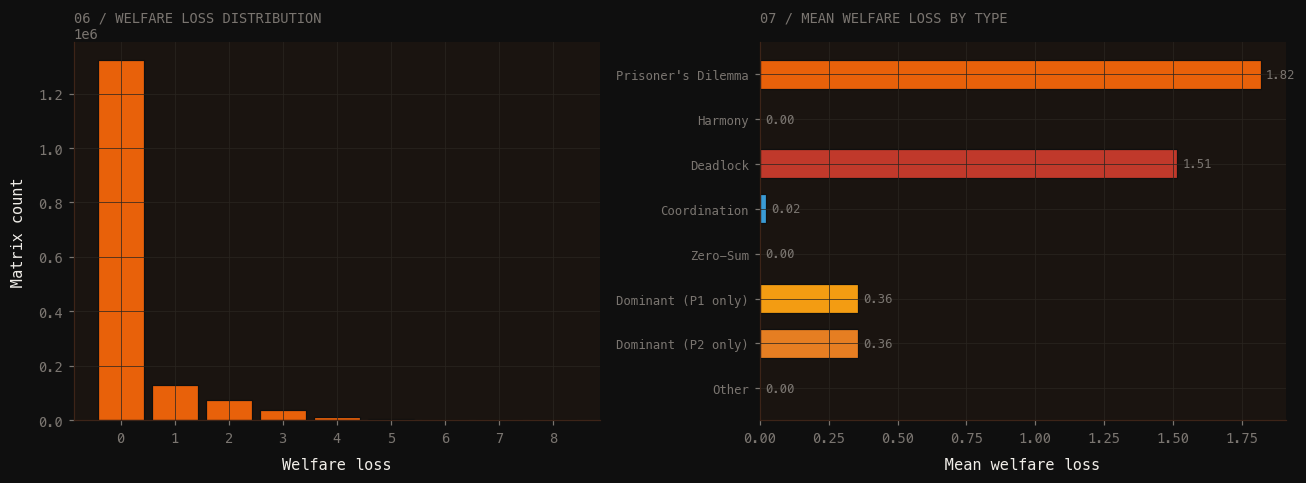

In [18]:
# ── Chart 06-D: Welfare loss distribution ───────────────────────────────────
#
# "Welfare loss" = max possible social welfare (p1+p2) MINUS the welfare
# achieved at the best NE.  Zero means the NE is socially optimal.
# Positive means society is leaving value on the table.
#
# This is the quantitative heart of the social-dilemma concept.

if edf is not None:
    has_ne = edf[edf['num_equilibria'] > 0]

    welfare_counts = has_ne['welfare_loss'].value_counts().sort_index()
    total_ne = len(has_ne)

    print('Welfare loss distribution (matrices with ≥1 NE):')
    print(f'  welfare_loss == 0 : {welfare_counts.get(0,0):>9,}  '
          f'({100*welfare_counts.get(0,0)/total_ne:.2f}%)  ← no social loss')
    print(f'  welfare_loss  > 0 : {total_ne - welfare_counts.get(0,0):>9,}  '
          f'({100*(total_ne - welfare_counts.get(0,0))/total_ne:.2f}%)  ← some welfare left on table')
    print()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # Left: full welfare loss histogram
    ax = axes[0]
    wl_vals = has_ne['welfare_loss'].values
    max_wl   = int(wl_vals.max())
    bins = np.arange(-0.5, max_wl + 1.5, 1)

    ax.hist(wl_vals, bins=bins, color=ACCENT, edgecolor=BG_PAGE,
            linewidth=0.8, rwidth=0.85)
    ax.set_xlabel('Welfare loss', labelpad=8)
    ax.set_ylabel('Matrix count', labelpad=8)
    ax.set_title('06 / WELFARE LOSS DISTRIBUTION',
                 loc='left', fontfamily='monospace', fontsize=9, color=TEXT_MUT)
    ax.set_xticks(range(max_wl + 1))

    # Right: welfare loss > 0 by game type (mean welfare loss)
    ax2 = axes[1]
    gt_wl = (
        has_ne.groupby('game_type')['welfare_loss']
              .mean()
              .reindex(GAME_TYPE_ORDER)
              .dropna()
    )
    y_pos = np.arange(len(gt_wl))
    ax2.barh(y_pos, gt_wl.values,
             color=[GAME_TYPE_COLORS.get(t, TEXT_DIM) for t in gt_wl.index],
             edgecolor=BG_PAGE, linewidth=0.8, height=0.65)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(gt_wl.index, fontsize=8)
    ax2.set_xlabel('Mean welfare loss', labelpad=8)
    ax2.set_title('07 / MEAN WELFARE LOSS BY TYPE',
                  loc='left', fontfamily='monospace', fontsize=9, color=TEXT_MUT)
    ax2.invert_yaxis()

    for i, v in enumerate(gt_wl.values):
        ax2.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=8, color=TEXT_MUT)

    plt.tight_layout()
    plt.show()


In [19]:
# ── 06-E: Example matrices per game type ─────────────────────────────────────
#
# For each named game type, pull one real example from the dataset and
# display its payoff matrix and structural properties.
#
# This bridges the abstract classification back to concrete cases —
# the same thing the Gradio Tab 05 does interactively.

from IPython.display import HTML, display

def render_matrix_card(row, title_override=None):
    """Return HTML for a single classified matrix card."""
    # Extract payoffs (supports both old and new column formats)
    if 'r0c0_p1' in row.index:
        cells = [
            (row['r0c0_p1'], row['r0c0_p2']),
            (row['r0c1_p1'], row['r0c1_p2']),
            (row['r1c0_p1'], row['r1c0_p2']),
            (row['r1c1_p1'], row['r1c1_p2']),
        ]
    else:
        cells = [
            (row['top_left_1'],    row['top_left_2']),
            (row['top_right_1'],   row['top_right_2']),
            (row['bottom_left_1'], row['bottom_left_2']),
            (row['bottom_right_1'],row['bottom_right_2']),
        ]

    label = row['game_type']
    badge_color = {
        "Prisoner's Dilemma": "#E8610A",
        "Harmony":            "#4CAF82",
        "Deadlock":           "#C0392B",
        "Coordination":       "#3A9BD5",
        "Zero-Sum":           "#9B59B6",
        "Dominant (P1 only)": "#F39C12",
        "Dominant (P2 only)": "#E67E22",
        "No Equilibrium":     "#7A7570",
        "Other":              "#4A4540",
    }.get(label, '#7A7570')

    # Reconstruct NE set from num_equilibria + equilibrium_positions
    import ast
    try:
        ne_set = set(tuple(p) for p in ast.literal_eval(str(row.get('equilibrium_positions', '[]'))))
    except Exception:
        ne_set = set()

    cell_html = ''
    for idx, (p1, p2) in enumerate(cells):
        r, c = divmod(idx, 2)
        is_ne   = (r, c) in ne_set
        bg      = '#2A1E14' if is_ne else '#15110D'
        color   = '#E8610A' if is_ne else '#7A7570'
        star    = ' ★' if is_ne else ''
        cell_html += (
            f"<td style='padding:10px 18px;border:1px solid #3D2418;"
            f"background:{bg};text-align:center;color:{color};"
            f"font-family:monospace;font-size:0.9rem;"
            f"font-weight:{'600' if is_ne else '400'}'>"
            f"({int(p1)}, {int(p2)}){star}</td>"
        )
        if c == 1 and r == 0:
            cell_html += '</tr><tr>'

    props_items = ''
    for key, label_text in [
        ('both_dominant',    'Both dominant'),
        ('is_zero_sum',      'Zero-sum'),
        ('is_symmetric',     'Symmetric'),
        ('welfare_loss',     'Welfare loss'),
    ]:
        val = row.get(key, '—')
        if isinstance(val, bool) or str(val) in ('True', 'False'):
            v_display = '✓' if str(val) == 'True' else '✗'
            v_color   = '#4CAF82' if str(val) == 'True' else '#4A4540'
        else:
            v_display = str(int(float(val))) if val != '—' else '—'
            v_color   = '#E8610A' if float(val) > 0 else '#4CAF82'
        props_items += (
            f"<span style='font-size:0.75rem;color:#7A7570;font-family:monospace'>"
            f"{label_text}:</span> "
            f"<span style='color:{v_color};font-weight:600;font-family:monospace'>"
            f"{v_display}</span> &nbsp;&nbsp; "
        )

    game_label = title_override or row['game_type']
    return f"""
    <div style='display:inline-block;background:#1A1410;border:1px solid #3D2418;
                border-radius:6px;padding:1rem 1.2rem;margin:0.5rem;
                vertical-align:top;min-width:220px'>
      <div style='font-family:sans-serif;font-weight:700;
                  font-size:1rem;color:{badge_color};margin-bottom:0.6rem'>
        {game_label}
      </div>
      <table style='border-collapse:collapse;margin:0 auto 0.6rem'>
        <tr>{cell_html}</tr>
      </table>
      <div style='font-size:0.78rem;margin-top:0.4rem'>{props_items}</div>
    </div>
    """

if edf is not None:
    cards_html = '<div style="background:#0F0F0F;padding:1rem;border-radius:8px">'
    cards_html += '<h4 style="font-family:monospace;color:#7A7570;margin-bottom:0.8rem">One real example per game type (sampled from enriched dataset)</h4>'

    for gt in GAME_TYPE_ORDER:
        subset = edf[edf['game_type'] == gt]
        if len(subset) > 0:
            sample = subset.sample(1, random_state=42).iloc[0]
            cards_html += render_matrix_card(sample)

    cards_html += '</div>'
    display(HTML(cards_html))


"(4, 3)","(0, 4) ★"
"(3, 0)","(0, 0) ★"
"(4, 2)","(4, 5) ★"
"(3, 2)","(2, 5)"
"(0, 0)","(3, 0)"
"(3, 2) ★","(5, 1)"
"(5, 5) ★","(1, 1)"
"(1, 1)","(5, 5) ★"
"(4, 0) ★","(4, 0) ★"
"(0, 4)","(1, 3)"
"(1, 1)","(0, 0)"


### Statistical test: does the game type distribution change significantly across ranges?

The stacked bar above shows that game type proportions shift between ranges. The chi-squared test of independence quantifies whether that shift is meaningful.

Since these are exhaustive datasets — every possible matrix — not samples, any difference is real by definition. The chi-squared p-value is essentially always 0 here. The useful number is **Cramér's V**, which measures effect size (how *much* the distributions differ, independent of dataset size).


In [20]:
# ── 06-F: Chi-squared test across ranges ─────────────────────────────────────
from scipy.stats import chi2_contingency
import numpy as np

_sk = lambda p: (p.stem.split('_')[1], int(p.stem.split('_to_')[-1]))
enriched_files = [p for p in sorted(ENRICHED_DIR.glob('matrices_*.csv'), key=_sk)
                  if p.stat().st_size <= MAX_NB_BYTES]

if len(enriched_files) >= 2:
    # Build contingency table: rows = ranges, cols = game types
    counts_per_range = {}
    for fpath in enriched_files:
        d = pd.read_csv(fpath)
        stem  = fpath.stem.replace('matrices_', '')
        parts = stem.split('_')
        try:
            label = f"{parts[0].replace('x','×')} · {parts[1]}–{parts[3]}"
        except IndexError:
            label = stem
        counts_per_range[label] = d['game_type'].value_counts()

    # Align all ranges to the same game type columns
    all_types = sorted(set(t for c in counts_per_range.values() for t in c.index))
    contingency = np.array([
        [counts_per_range[lbl].get(gt, 0) for gt in all_types]
        for lbl in counts_per_range
    ])

    chi2, p, dof, expected = chi2_contingency(contingency)

    # Cramér's V — effect size, 0=no effect, 1=perfect association
    n = contingency.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

    print(f'Chi-squared test of game type distribution across {len(counts_per_range)} ranges')
    print('─' * 55)
    print(f'  chi²  = {chi2:,.2f}')
    print(f'  df    = {dof}')
    print(f'  p     = {p:.2e}  {"← reject null (distributions differ)" if p < 0.05 else "← cannot reject null"}')
    print(f"  Cramér's V = {cramers_v:.4f}  {'(strong effect)' if cramers_v > 0.3 else '(moderate)' if cramers_v > 0.1 else '(weak)'}")
    print()
    print('Note: with exhaustive datasets, p is essentially always 0 — the key insight')
    print("is Cramér's V, which measures HOW DIFFERENT the distributions actually are.")
    print()

    # Show the contingency table as a formatted DataFrame
    ct_df = pd.DataFrame(contingency, index=list(counts_per_range.keys()), columns=all_types)
    print('Contingency table (raw counts):')
    display(ct_df)
else:
    print(f'Need ≥2 enriched datasets for the chi-squared test.')
    print(f'Found {len(enriched_files)} — run: python enrich_datasets.py')


Chi-squared test of game type distribution across 4 ranges
───────────────────────────────────────────────────────
  chi²  = 71,679.69
  df    = 24
  p     = 0.00e+00  ← reject null (distributions differ)
  Cramér's V = 0.1089  (moderate)

Note: with exhaustive datasets, p is essentially always 0 — the key insight
is Cramér's V, which measures HOW DIFFERENT the distributions actually are.

Contingency table (raw counts):


,Coordination,Deadlock,Dominant (P1 only),Dominant (P2 only),Harmony,No Equilibrium,Other,Prisoner's Dilemma,Zero-Sum
2×2 · 0–2,18,80,1130,1130,3680,144,144,120,115
2×2 · 0–3,72,1468,13220,13220,30252,2508,2520,1824,452
2×2 · 0–5,450,62336,380392,380392,597820,100524,100800,53648,3254
3×3 · 0–1,196,0,63384,63384,90936,1254,42476,0,514


---
## 07 / MIXED-STRATEGY EQUILIBRIUM ANALYSIS

When no pure-strategy NE exists, Nash's theorem guarantees a mixed-strategy equilibrium always exists. For a 2×2 game the maths resolves to two equations:
- **p** (P1's probability of playing Row 0) is found by making P2 indifferent between columns
- **q** (P2's probability of playing Col 0) is found by making P1 indifferent between rows

This section covers the ~6% of matrices with no pure NE — how the mixing probabilities distribute and how welfare at the mixed NE compares to the social optimum.


In [21]:
import ast

# Load the 0-5 enriched dataset (or use whatever is available)
ENRICHED_CSV = DATASETS_DIR / "enriched" / "matrices_2x2_0_to_5.csv"
if not ENRICHED_CSV.exists():
    # Fall back to smaller dataset
    ENRICHED_CSV = sorted((DATASETS_DIR / "enriched").glob("matrices_*.csv"))[-1]
print(f"Loading {ENRICHED_CSV.name}...")

edf = pd.read_csv(
    ENRICHED_CSV,
    usecols=["game_type", "num_equilibria", "max_welfare",
             "mixed_exists", "mixed_p", "mixed_q",
             "mixed_payoff_p1", "mixed_payoff_p2"],
)

no_ne = edf[edf["num_equilibria"] == 0].copy()
mixed_valid = no_ne[no_ne["mixed_exists"] == True].copy()
mixed_valid["mixed_welfare"] = mixed_valid["mixed_payoff_p1"] + mixed_valid["mixed_payoff_p2"]

print(f"Matrices with 0 pure NE:          {len(no_ne):,}  ({100*len(no_ne)/len(edf):.2f}% of total)")
print(f"With valid mixed-strategy NE:     {len(mixed_valid):,}  ({100*len(mixed_valid)/len(no_ne):.2f}% of 0-pure-NE)")
print(f"Degenerate (no valid mixed NE):   {len(no_ne) - len(mixed_valid):,}")


Loading matrices_2x2_0_to_5.csv...


Matrices with 0 pure NE:          101,250  (6.03% of total)
With valid mixed-strategy NE:     101,250  (100.00% of 0-pure-NE)
Degenerate (no valid mixed NE):   0


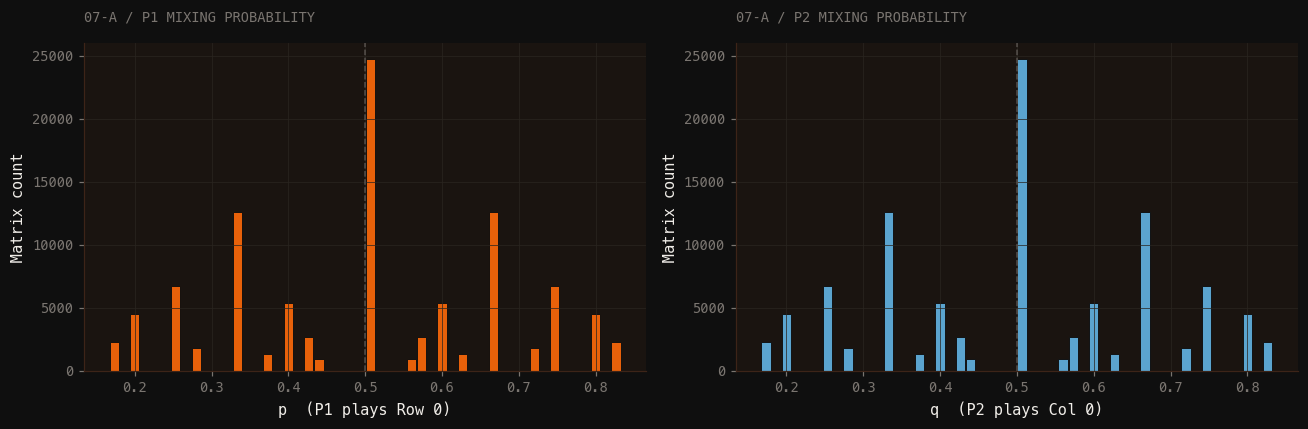

Median p: 0.5000
Median q: 0.5000


In [22]:
if 'mixed_valid' not in dir():
    import sys; sys.path.insert(0, str(Path('engine').resolve()))
    import pandas as _pd; import numpy as _np
    _e = _pd.read_csv(Path('engine') / 'datasets' / 'enriched' / 'matrices_2x2_0_to_5.csv',
                      usecols=["game_type","num_equilibria","max_welfare",
                                "mixed_exists","mixed_p","mixed_q",
                                "mixed_payoff_p1","mixed_payoff_p2"])
    _no_ne = _e[_e["num_equilibria"] == 0].copy()
    mixed_valid = _no_ne[_no_ne["mixed_exists"] == True].copy()
    mixed_valid["mixed_welfare"] = mixed_valid["mixed_payoff_p1"] + mixed_valid["mixed_payoff_p2"]
    del _e, _no_ne

# ── Chart 07-A: P1 and P2 mixing probability distributions ──────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(mixed_valid["mixed_p"], bins=50, color=ACCENT, edgecolor=BG_PAGE,
         linewidth=0.6, rwidth=0.9)
ax1.set_xlabel("p  (P1 plays Row 0)", fontsize=10)
ax1.set_ylabel("Matrix count", fontsize=10)
ax1.set_title("07-A / P1 MIXING PROBABILITY", loc="left",
              fontfamily="monospace", fontsize=9, color=TEXT_MUT)
ax1.axvline(0.5, color=TEXT_MUT, linewidth=1, linestyle="--", alpha=0.6)

ax2.hist(mixed_valid["mixed_q"], bins=50, color=PALETTE[1], edgecolor=BG_PAGE,
         linewidth=0.6, rwidth=0.9)
ax2.set_xlabel("q  (P2 plays Col 0)", fontsize=10)
ax2.set_ylabel("Matrix count", fontsize=10)
ax2.set_title("07-A / P2 MIXING PROBABILITY", loc="left",
              fontfamily="monospace", fontsize=9, color=TEXT_MUT)
ax2.axvline(0.5, color=TEXT_MUT, linewidth=1, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Median p: {mixed_valid['mixed_p'].median():.4f}")
print(f"Median q: {mixed_valid['mixed_q'].median():.4f}")


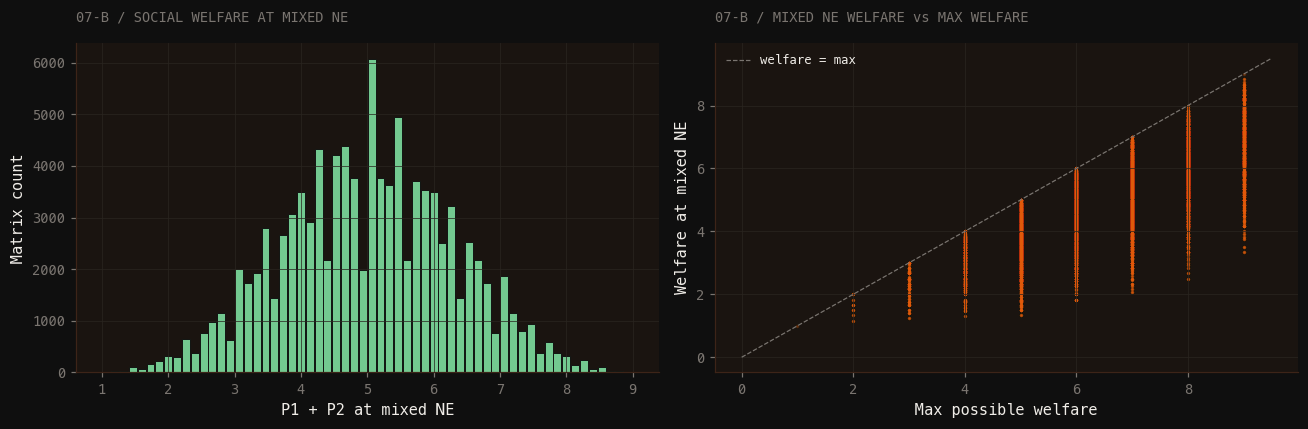

Mean welfare loss at mixed NE: 1.641
% with zero welfare loss:      0.7%


In [23]:
if 'mixed_valid' not in dir():
    import sys; sys.path.insert(0, str(Path('engine').resolve()))
    import pandas as _pd; import numpy as _np
    _e = _pd.read_csv(Path('engine') / 'datasets' / 'enriched' / 'matrices_2x2_0_to_5.csv',
                      usecols=["game_type","num_equilibria","max_welfare",
                                "mixed_exists","mixed_p","mixed_q",
                                "mixed_payoff_p1","mixed_payoff_p2"])
    _no_ne = _e[_e["num_equilibria"] == 0].copy()
    mixed_valid = _no_ne[_no_ne["mixed_exists"] == True].copy()
    mixed_valid["mixed_welfare"] = mixed_valid["mixed_payoff_p1"] + mixed_valid["mixed_payoff_p2"]
    del _e, _no_ne

# ── Chart 07-B: Welfare at mixed NE vs max possible welfare ─────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram of mixed welfare
ax1.hist(mixed_valid["mixed_welfare"], bins=60, color=PALETTE[2], edgecolor=BG_PAGE,
         linewidth=0.6, rwidth=0.9)
ax1.set_xlabel("P1 + P2 at mixed NE", fontsize=10)
ax1.set_ylabel("Matrix count", fontsize=10)
ax1.set_title("07-B / SOCIAL WELFARE AT MIXED NE", loc="left",
              fontfamily="monospace", fontsize=9, color=TEXT_MUT)

# Right: scatter mixed welfare vs max welfare
ax2.scatter(mixed_valid["max_welfare"], mixed_valid["mixed_welfare"],
            s=1.5, alpha=0.12, color=ACCENT, rasterized=True)
lim_max = max(mixed_valid["max_welfare"].max(), mixed_valid["mixed_welfare"].max()) + 0.5
ax2.plot([0, lim_max], [0, lim_max], color=TEXT_MUT, linewidth=0.8,
         linestyle="--", label="welfare = max")
ax2.set_xlabel("Max possible welfare", fontsize=10)
ax2.set_ylabel("Welfare at mixed NE", fontsize=10)
ax2.set_title("07-B / MIXED NE WELFARE vs MAX WELFARE", loc="left",
              fontfamily="monospace", fontsize=9, color=TEXT_MUT)
ax2.legend(fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

mixed_welfare_loss = mixed_valid["max_welfare"] - mixed_valid["mixed_welfare"]
print(f"Mean welfare loss at mixed NE: {mixed_welfare_loss.mean():.3f}")
print(f"% with zero welfare loss:      {100*(mixed_welfare_loss <= 0).mean():.1f}%")


---
## 08 / PAYOFF ASYMMETRY AT NASH EQUILIBRIA

A Nash equilibrium says neither player wants to deviate — it says nothing about whether the outcome is *fair*. How often do P1 and P2 receive equal payoffs at the NE, and does that vary by game type or Pareto efficiency?


In [24]:
# ── Load enriched data for payoff asymmetry analysis ──────────────────────
asym_df = pd.read_csv(
    ENRICHED_CSV,
    usecols=["game_type", "num_equilibria", "all_ne_pareto_eff",
             "ne_has_equal_payoffs", "ne_mean_abs_diff", "welfare_loss"],
)
asym_df["ne_mean_abs_diff"] = pd.to_numeric(asym_df["ne_mean_abs_diff"], errors="coerce")

has_ne = asym_df[asym_df["num_equilibria"] > 0].copy()

overall_pct = 100 * (has_ne["ne_has_equal_payoffs"] == True).sum() / len(has_ne)
print(f"Matrices with at least 1 pure NE: {len(has_ne):,}")
print(f"% where any NE has equal payoffs: {overall_pct:.2f}%")
print()
print("By game type:")
for gt in [t for t in GAME_TYPE_ORDER if t in has_ne["game_type"].unique()]:
    sub = has_ne[has_ne["game_type"] == gt]
    pct = 100 * (sub["ne_has_equal_payoffs"] == True).sum() / len(sub)
    print(f"  {gt:<25s}  {pct:5.1f}%  (n={len(sub):,})")


Matrices with at least 1 pure NE: 1,578,366
% where any NE has equal payoffs: 28.03%

By game type:


  Prisoner's Dilemma          18.2%  (n=53,648)
  Harmony                     31.0%  (n=597,820)
  Deadlock                    12.0%  (n=62,336)
  Coordination                62.2%  (n=450)
  Zero-Sum                    14.2%  (n=2,528)
  Dominant (P1 only)          25.7%  (n=380,392)
  Dominant (P2 only)          25.7%  (n=380,392)


  Other                       42.8%  (n=100,800)


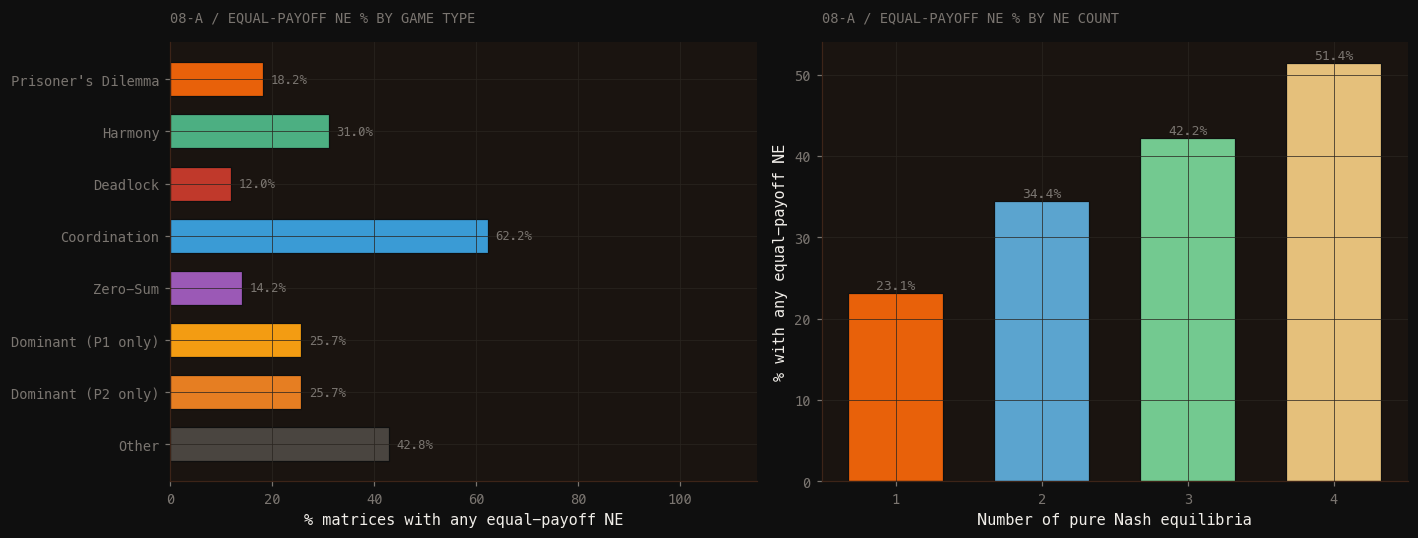

In [25]:
if 'has_ne' not in dir() or 'ne_mean_abs_diff' not in has_ne.columns:
    import sys; sys.path.insert(0, str(Path('engine').resolve()))
    import pandas as _pd; import numpy as _np
    _a = _pd.read_csv(Path('engine') / 'datasets' / 'enriched' / 'matrices_2x2_0_to_5.csv',
                      usecols=["game_type","num_equilibria","all_ne_pareto_eff",
                                "ne_has_equal_payoffs","ne_mean_abs_diff","welfare_loss"])
    _a["ne_mean_abs_diff"] = _pd.to_numeric(_a["ne_mean_abs_diff"], errors="coerce")
    has_ne = _a[_a["num_equilibria"] > 0].copy()
    del _a

# ── Chart 08-A: % equal-payoff NE by game type and by NE count ──────────────
ordered_types = [t for t in GAME_TYPE_ORDER
                 if t in has_ne["game_type"].unique() and t != "No Equilibrium"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: by game type (horizontal bar)
eq_pcts = []
for gt in ordered_types:
    sub = has_ne[has_ne["game_type"] == gt]
    eq_pcts.append(100 * (sub["ne_has_equal_payoffs"] == True).sum() / len(sub))

colors = [GAME_TYPE_COLORS.get(t, TEXT_MUT) for t in ordered_types]
y_pos = np.arange(len(ordered_types))
ax1.barh(y_pos, eq_pcts, color=colors, edgecolor=BG_PAGE, linewidth=0.8, height=0.65)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(ordered_types, fontsize=9)
ax1.set_xlabel("% matrices with any equal-payoff NE", fontsize=10)
ax1.set_title("08-A / EQUAL-PAYOFF NE % BY GAME TYPE", loc="left",
              fontfamily="monospace", fontsize=9, color=TEXT_MUT)
ax1.invert_yaxis()
ax1.set_xlim(0, 115)
for i, v in enumerate(eq_pcts):
    ax1.text(v + 1.5, i, f"{v:.1f}%", va="center", fontsize=8, color=TEXT_MUT)

# Right: by NE count
ne_counts = sorted(has_ne["num_equilibria"].unique())
eq_by_ne = [100 * (has_ne[has_ne["num_equilibria"]==n]["ne_has_equal_payoffs"] == True).sum()
            / len(has_ne[has_ne["num_equilibria"]==n]) for n in ne_counts]
bar_colors = PALETTE[:len(ne_counts)]
ax2.bar([str(n) for n in ne_counts], eq_by_ne,
        color=bar_colors, edgecolor=BG_PAGE, linewidth=0.8, width=0.65)
ax2.set_xlabel("Number of pure Nash equilibria", fontsize=10)
ax2.set_ylabel("% with any equal-payoff NE", fontsize=10)
ax2.set_title("08-A / EQUAL-PAYOFF NE % BY NE COUNT", loc="left",
              fontfamily="monospace", fontsize=9, color=TEXT_MUT)
for i, v in enumerate(eq_by_ne):
    ax2.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=8.5, color=TEXT_MUT)

plt.tight_layout()
plt.show()


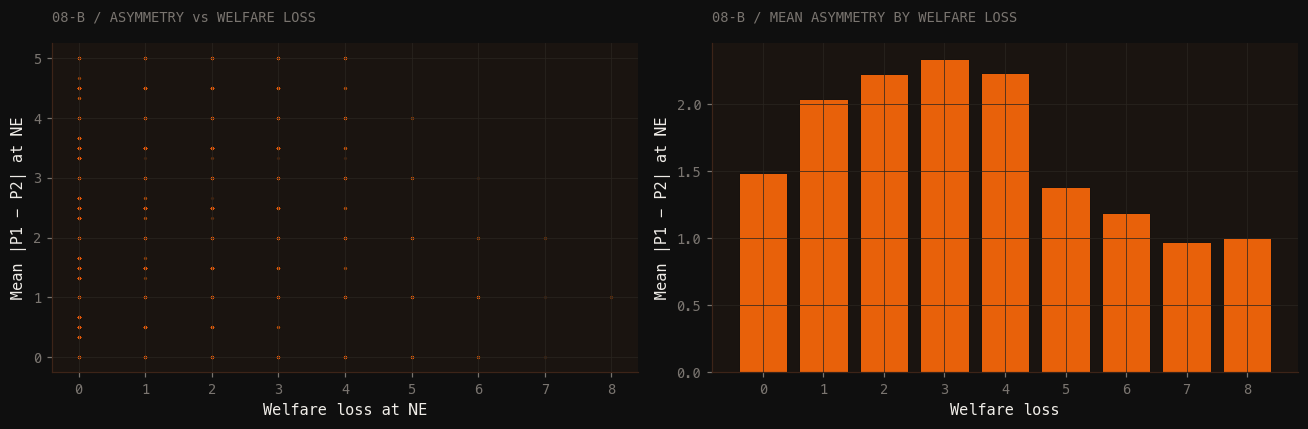

Pearson r (welfare_loss, ne_mean_abs_diff) = 0.1844


In [26]:
if 'has_ne' not in dir() or 'ne_mean_abs_diff' not in has_ne.columns:
    import sys; sys.path.insert(0, str(Path('engine').resolve()))
    import pandas as _pd; import numpy as _np
    _a = _pd.read_csv(Path('engine') / 'datasets' / 'enriched' / 'matrices_2x2_0_to_5.csv',
                      usecols=["game_type","num_equilibria","all_ne_pareto_eff",
                                "ne_has_equal_payoffs","ne_mean_abs_diff","welfare_loss"])
    _a["ne_mean_abs_diff"] = _pd.to_numeric(_a["ne_mean_abs_diff"], errors="coerce")
    has_ne = _a[_a["num_equilibria"] > 0].copy()
    del _a

# ── Chart 08-B: Mean |P1-P2| vs welfare loss — correlation scatter ───────────
plot_df = has_ne[["ne_mean_abs_diff", "welfare_loss"]].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: scatter asymmetry vs welfare loss (random subsample for readability)
sample = plot_df.sample(min(50_000, len(plot_df)), random_state=42)
ax1.scatter(sample["welfare_loss"], sample["ne_mean_abs_diff"],
            s=1.5, alpha=0.15, color=ACCENT, rasterized=True)
ax1.set_xlabel("Welfare loss at NE", fontsize=10)
ax1.set_ylabel("Mean |P1 − P2| at NE", fontsize=10)
ax1.set_title("08-B / ASYMMETRY vs WELFARE LOSS", loc="left",
              fontfamily="monospace", fontsize=9, color=TEXT_MUT)

# Right: mean asymmetry by welfare_loss bucket
max_wl = int(plot_df["welfare_loss"].max())
wl_buckets = list(range(max_wl + 1))
mean_asym = [plot_df[plot_df["welfare_loss"]==wl]["ne_mean_abs_diff"].mean()
             for wl in wl_buckets]
ax2.bar(wl_buckets, mean_asym, color=ACCENT, edgecolor=BG_PAGE,
        linewidth=0.6, width=0.8)
ax2.set_xlabel("Welfare loss", fontsize=10)
ax2.set_ylabel("Mean |P1 − P2| at NE", fontsize=10)
ax2.set_title("08-B / MEAN ASYMMETRY BY WELFARE LOSS", loc="left",
              fontfamily="monospace", fontsize=9, color=TEXT_MUT)
if max_wl <= 20:
    ax2.set_xticks(wl_buckets)

plt.tight_layout()
plt.show()

# Correlation coefficient
corr = plot_df.corr()["ne_mean_abs_diff"]["welfare_loss"]
print(f"Pearson r (welfare_loss, ne_mean_abs_diff) = {corr:.4f}")


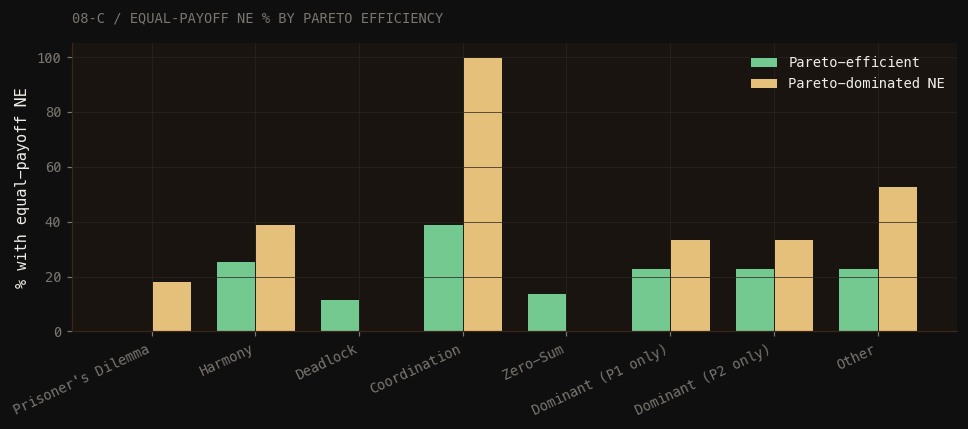

In [27]:
if 'has_ne' not in dir() or 'ne_mean_abs_diff' not in has_ne.columns:
    import sys; sys.path.insert(0, str(Path('engine').resolve()))
    import pandas as _pd; import numpy as _np
    _a = _pd.read_csv(Path('engine') / 'datasets' / 'enriched' / 'matrices_2x2_0_to_5.csv',
                      usecols=["game_type","num_equilibria","all_ne_pareto_eff",
                                "ne_has_equal_payoffs","ne_mean_abs_diff","welfare_loss"])
    _a["ne_mean_abs_diff"] = _pd.to_numeric(_a["ne_mean_abs_diff"], errors="coerce")
    has_ne = _a[_a["num_equilibria"] > 0].copy()
    del _a

# ── Chart 08-C: Equal-payoff NE % split by Pareto efficiency ────────────────
pareto_eff   = has_ne[has_ne["all_ne_pareto_eff"] == True]
pareto_ineff = has_ne[has_ne["all_ne_pareto_eff"] == False]

groups = [("Pareto-efficient", pareto_eff, PALETTE[2]),
          ("Pareto-dominated NE", pareto_ineff, PALETTE[3])]

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(ordered_types))
width = 0.38

for offset, (group_label, group_df, col) in zip([-width/2, width/2], groups):
    pcts = []
    for gt in ordered_types:
        sub = group_df[group_df["game_type"] == gt]
        if len(sub) == 0:
            pcts.append(0)
            continue
        pcts.append(100 * (sub["ne_has_equal_payoffs"] == True).sum() / len(sub))
    ax.bar(x + offset, pcts, width, label=group_label,
           color=col, edgecolor=BG_PAGE, linewidth=0.6)

ax.set_xticks(x)
ax.set_xticklabels(ordered_types, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("% with equal-payoff NE", fontsize=10)
ax.set_title("08-C / EQUAL-PAYOFF NE % BY PARETO EFFICIENCY", loc="left",
             fontfamily="monospace", fontsize=9, color=TEXT_MUT)
ax.legend(fontsize=9, frameon=False)
plt.tight_layout()
plt.show()
